# XGBoost Tuning

| | |
|---|---|
| **Algorithm** | XGBRegressor |
| **Dataset** | California Housing |
| **Task** | Regression (집값 예측) |
| **Metric** | RMSE, MAE, R² — 80/20 train-test split |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **Feature Engineering** | rooms/household, bedrooms/room, population/household 파생 피처 추가 | 트리가 포착하기 어려운 나눗셈 관계를 명시적으로 제공 |
| 2 | **Early Stopping** | 검증 손실이 개선되지 않으면 자동 중단 | 과적합 없이 최적 n_estimators 자동 결정 |
| 3 | **GridSearchCV** | min_child_weight + gamma 탐색 | 트리 분기 조건 제어 → 과적합 방지 |

## Imports
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## Data Loading
---
- `housing.csv`: California Housing 데이터 (20,640 samples, 9 features)
- `total_bedrooms`: 결측값 → median 대체
- `ocean_proximity`: LabelEncoder → 정수 인코딩

In [2]:
df = pd.read_csv('../datasets/housing.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(20640, 10)
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

X = df.drop(columns='median_house_value')
y = df['median_house_value'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Base Model
---
- XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05)
- subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0

In [4]:
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:30s}  RMSE: {rmse:,.0f}  MAE: {mae:,.0f}  R²: {r2:.4f}')
    return rmse, mae, r2

In [5]:
base_model = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
base_rmse, base_mae, base_r2 = evaluate(y_test, y_pred_base, 'Base')

Base                            RMSE: 49,345  MAE: 33,212  R²: 0.8142


## Tuning 1: Feature Engineering
---
- XGBoost는 트리 기반 → 피처 간 나눗셈/비율 관계를 스스로 근사하기 어렵다
- 파생 피처를 직접 만들면 해당 관계를 더 쉽게 학습한다

| 파생 피처 | 계산 | 의미 |
|---|---|---|
| `rooms_per_household` | total_rooms / households | 가구당 방 수 — 주거 밀도 |
| `bedrooms_per_room` | total_bedrooms / total_rooms | 침실 비율 — 주거 유형 |
| `population_per_household` | population / households | 가구당 인구 — 가족 규모 |

In [6]:
def add_features(df):
    df = df.copy()
    df['rooms_per_household']      = df['total_rooms'] / df['households']
    df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population'] / df['households']
    return df

X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

fe_model = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
fe_model.fit(X_train_fe, y_train)
y_pred_fe = fe_model.predict(X_test_fe)
fe_rmse, fe_mae, fe_r2 = evaluate(y_test, y_pred_fe, 'Feature Engineering')

Feature Engineering             RMSE: 48,573  MAE: 32,592  R²: 0.8200


## Tuning 2: Early Stopping
---
- n_estimators=500으로 고정하면 과적합 지점을 모른 채 학습이 계속된다
- Early Stopping: 검증 세트 손실이 `early_stopping_rounds` 동안 개선 없으면 자동 중단
- `eval_set`은 반드시 별도 validation set을 사용 (test set 사용 시 정보 누수)

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_fe, y_train, test_size=0.1, random_state=42)

es_model = XGBRegressor(
    n_estimators=2000, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    early_stopping_rounds=50,
    random_state=42, n_jobs=-1
)
es_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {es_model.best_iteration}')
y_pred_es = es_model.predict(X_test_fe)
es_rmse, es_mae, es_r2 = evaluate(y_test, y_pred_es, 'Early Stopping')

Best iteration: 1083
Early Stopping                  RMSE: 46,370  MAE: 30,678  R²: 0.8359


## Tuning 3: GridSearchCV — min_child_weight + gamma
---

| 파라미터 | 역할 | 작을 때 | 클 때 |
|---|---|---|---|
| `min_child_weight` | leaf 노드 최소 Hessian 합계 | 작은 그룹도 분기 → 과적합 | 분기 억제 → 단순한 트리 |
| `gamma` | 분기 시 최소 손실 감소량 | 모든 분기 허용 | 손실 개선 >= gamma 일 때만 분기 |

- Early Stopping에서 찾은 best_iteration을 n_estimators로 고정

In [8]:
param_grid = {
    'min_child_weight': [1, 3, 5, 10],
    'gamma':            [0, 0.1, 0.3, 0.5]
}

grid_model = XGBRegressor(
    n_estimators=es_model.best_iteration, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)

grid = GridSearchCV(grid_model, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train_fe, y_train)

print(f'Best params : {grid.best_params_}')
print(f'Best CV RMSE: {-grid.best_score_:,.0f}')

y_pred_best = grid.predict(X_test_fe)
best_rmse, best_mae, best_r2 = evaluate(y_test, y_pred_best, 'GridSearchCV')

Best params : {'gamma': 0, 'min_child_weight': 3}
Best CV RMSE: 46,597
GridSearchCV                    RMSE: 46,334  MAE: 30,753  R²: 0.8362


## Feature Importance
---

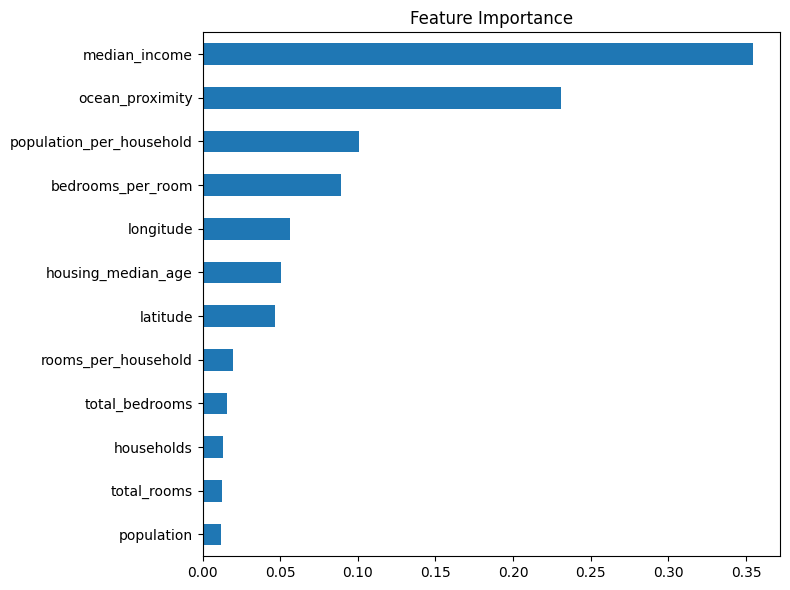

In [9]:
importance = pd.Series(
    grid.best_estimator_.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Results
---
- 80/20 train-test split 기준, 동일한 X_test_fe로 평가

         Model         RMSE          MAE       R2 RMSE Delta R2 Delta
          Base 49345.185655 33211.577852 0.814184         +0  +0.0000
  Feature Eng. 48573.307776 32591.986152 0.819952       -772  +0.0058
Early Stopping 46370.450613 30678.097825 0.835912     -2,975  +0.0217
  GridSearchCV 46334.380974 30753.237625 0.836168     -3,011  +0.0220


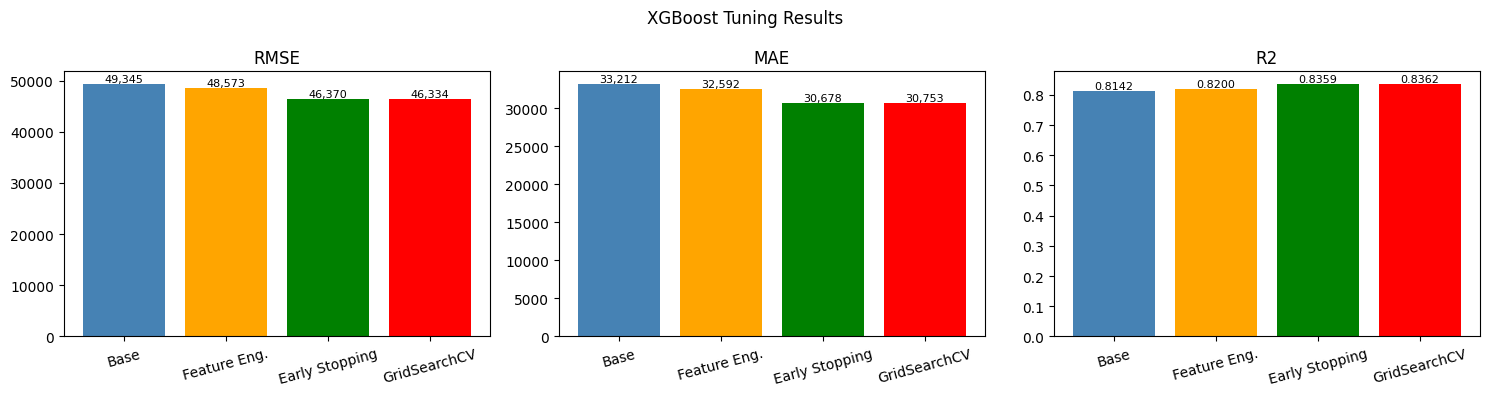

In [10]:
results = pd.DataFrame({
    'Model':  ['Base', 'Feature Eng.', 'Early Stopping', 'GridSearchCV'],
    'RMSE':   [base_rmse, fe_rmse, es_rmse, best_rmse],
    'MAE':    [base_mae,  fe_mae,  es_mae,  best_mae],
    'R2':     [base_r2,   fe_r2,   es_r2,   best_r2]
})
results['RMSE Delta'] = (results['RMSE'] - base_rmse).map(lambda x: f'{x:+,.0f}')
results['R2 Delta']   = (results['R2']   - base_r2  ).map(lambda x: f'{x:+.4f}')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(results['Model'], results[col], color=['steelblue', 'orange', 'green', 'red'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.0f}' if col != 'R2' else f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)
plt.suptitle('XGBoost Tuning Results')
plt.tight_layout()
plt.show()